# SIAM UQ 2026 Lattice and Kronecker

Author: Fred J. Hickernell + ChatGPT

This notebook supports the talk given on March 23, 2026 in Minneapolis

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/GeneratingRandomVectors.ipynb?flush_cache=true)

In [13]:
if "google.colab" in str(get_ipython()):
    print("⚡Note: Setup here can take a few minutes.")
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop
    !git clone https://github.com/QMCSoftware/MATH565Fall2025.git
    %cd MATH565Fall2025/notebooks
    print("\n✅ Colab setup complete.")
    print("   For faster performance, please install the qmcpy environment locally.")

### Import needed packages and initialize some parameters

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import qmcpy as qp
import time
from IPython.display import display, Markdown
import classlib as cl
import classlib.nbviz as nb

%matplotlib inline

rng = np.random.default_rng(20251222)

nb.init(use_tex=True)
colors = nb.TOL_BRIGHT
nb.configure(figpath="SIAMUQ26_figures", savefigs=True, imgfrmt="png")  #change to "...figures/..." to track
# nb.SAVEFIGS = False  # to disable saving

## Pictures of IID, Lattice and Kronecker
These are the two sets of sequences that we focus on

These are some parameters for our plot

In [15]:
d = 13  #the dimension used for these examples
d_horiz = np.array([1])
d_vert = np.arange(2,3)
  #the sample size used for these examples
axis_pad = 0.05
ms = 50

Here is a plot of the IID sequence for different values of $n$

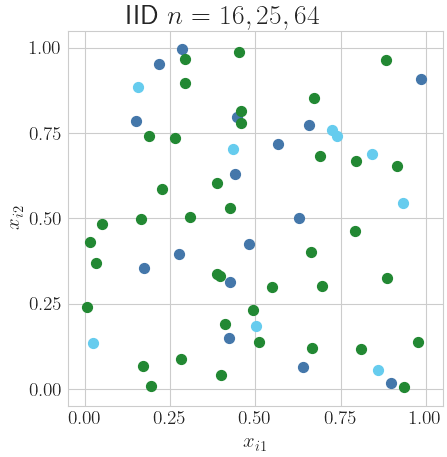

In [16]:
n_list = [16, 25, 64]
n_str = ", ".join(map(str, n_list))
fig,ax = qp.plot_proj(qp.IIDStdUniform(d), n=n_list, d_horizontal = d_horiz, d_vertical = d_vert, 
                      figfac = 5, axis_pad = axis_pad, where_title = 0.93, marker_size=ms,
                      fig_title = rf"IID $n = {n_str}$")
if nb.SAVEFIGS:
        nb.savefig(f"{n_list[-1]:.0f}lattice_pts_d{d:.0f}")

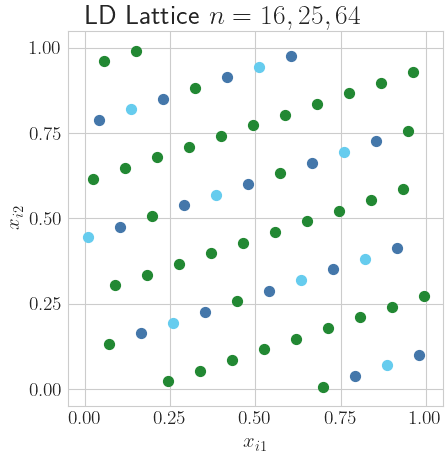

In [17]:
n_list = [16, 25, 64]
n_str = ", ".join(map(str, n_list))
fig,ax = qp.plot_proj(qp.Lattice(d), n=n_list, d_horizontal = d_horiz, d_vertical = d_vert, 
                      figfac = 5, axis_pad = axis_pad, where_title = 0.93, marker_size=ms,
                      fig_title = rf"LD Lattice $n = {n_str}$")
if nb.SAVEFIGS:
        nb.savefig(f"{n_list[-1]:.0f}lattice_pts_d{d:.0f}")

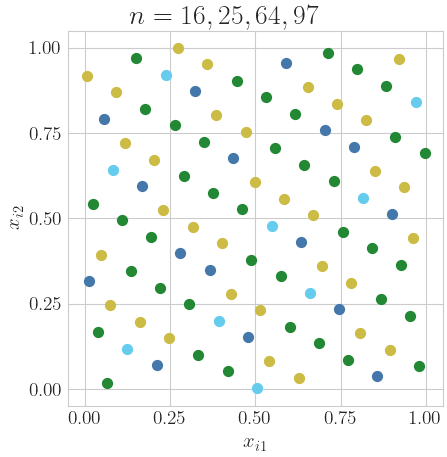

In [18]:
n_list.append(97)
n_str = ", ".join(map(str, n_list))
fig,ax = qp.plot_proj(qp.Kronecker(dimension = d,randomize = True), 
                      n=n_list, d_horizontal = d_horiz, d_vertical = d_vert, 
                      figfac = 5, axis_pad = axis_pad, where_title = 0.93, marker_size=ms,
                      fig_title = rf"$n = {n_str}$")
if nb.SAVEFIGS:
        nb.savefig(f"{n_list[-1]:.0f}Kronecker_pts_d{d:.0f}")

## Compute RMS Discrepancy for Kronecker and plot

In [19]:
gamma = np.arange(1,d+1)**-2.
n = 1_000_000

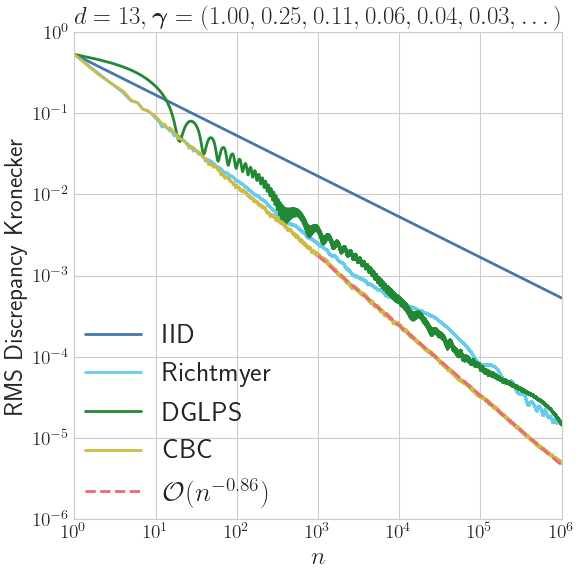

In [20]:
Kron_params = {
    "Richtmyer": "Richtmyer",
    "DGLPS": "Suzuki",
    "CBC": "CBC"
}

fig, ax = plt.subplots()
ax.set_aspect('equal')
n_vals = np.arange(1,n+1)
discIID = np.sqrt((-1+np.prod(1+gamma/6))/n_vals)
ax.loglog(n_vals,discIID, label = "IID")
Kron_discrepancies = {}   # dictionary to hold results
for label, which_alpha in Kron_params.items():
    disc = qp.Kronecker(dimension = d, generating_vector = which_alpha, 
                        randomize=False).periodic_discrepancy(n, gamma=gamma)
    Kron_discrepancies[label] = disc
    ax.loglog(n_vals, disc, label=f"{label}")

n_which_trend = np.array(n_vals[999:-1])  #ignore the first 1000 points
power, coef = nb.plot_log_trend_line(ax, n_vals, Kron_discrepancies["CBC"],
    n_which=n_which_trend)
    
ax.set_xlabel("$n$")
ax.set_ylabel("RMS Discrepancy Kronecker")
gamma_str = ", ".join(f"{g:.2f}" for g in gamma[:6])
if len(gamma) > 5:
    gamma_str += ", …"   # ellipsis at the end
ax.set_title(rf"$d = {d}, \boldsymbol{{\gamma}} = ({gamma_str})$")
ax.set_xlim(1, 1e6) 
ax.set_ylim(1e-6, 1)
ax.legend(loc="lower left",fontsize=20)
fig.tight_layout();
if nb.SAVEFIGS:
        nb.savefig(f"{n:.0f}Kronecker_RMSD_d{d:.0f}")

## Compute RMS Discrepancy for lattice and plot

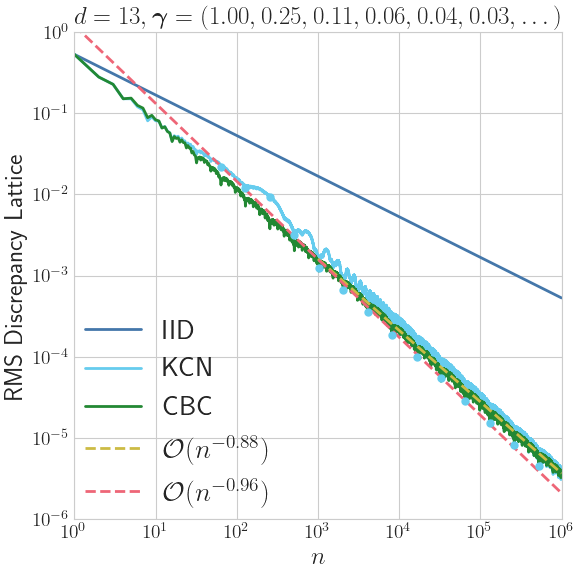

In [21]:
CBC_lattice_disc = np.loadtxt("CBC_Disc_d_13_n_1048576.txt",delimiter=",")
CBC_lattice_disc = CBC_lattice_disc[:n]
Kuo_lattice_disc = np.loadtxt("Kuo_Disc_d_13_n_1048576.txt",delimiter=",")
Kuo_lattice_disc = Kuo_lattice_disc[:n]

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.loglog(n_vals,discIID, label = "IID")
ax.loglog(n_vals,Kuo_lattice_disc, label = "KCN")
ax.loglog(n_vals,CBC_lattice_disc, label = "CBC")
power, coef = nb.plot_log_trend_line(ax, n_vals, CBC_lattice_disc,n_which=n_which_trend)
powers_of_two_idx = np.array([2**k for k in range(6,20)])-1  #look at preferred n
power_Kuo, coef_Kuo = nb.plot_log_trend_line(ax, n_vals, Kuo_lattice_disc, n_which=powers_of_two_idx, 
                                     w=1, endpoints = (1,n))
ax.loglog(n_vals[powers_of_two_idx],Kuo_lattice_disc[powers_of_two_idx],'.', ms=10, color=nb.TOL_BRIGHT["cyan"])

ax.set_xlabel("$n$")
ax.set_ylabel("RMS Discrepancy Lattice")
gamma_str = ", ".join(f"{g:.2f}" for g in gamma[:6])
if len(gamma) > 5:
    gamma_str += ", …"   # ellipsis at the end
ax.set_title(rf"$d = {d}, \boldsymbol{{\gamma}} = ({gamma_str})$")
ax.set_xlim(1, 1e6) 
ax.set_ylim(1e-6, 1)
ax.legend(loc="lower left",fontsize=20)
fig.tight_layout();
if nb.SAVEFIGS:
        nb.savefig(f"{n:.0f}Lattice_RMSD_d{d:.0f}")

## Compare RMS Discrepancy for lattice and Kronecker

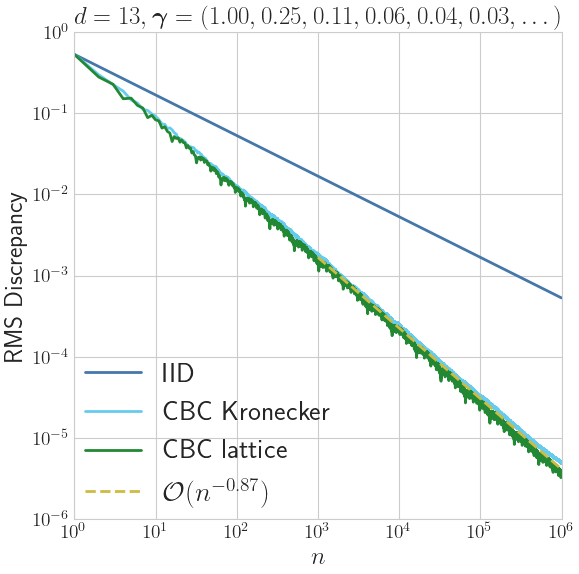

In [22]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.loglog(n_vals,discIID, label = "IID")
ax.loglog(n_vals,Kron_discrepancies["CBC"], label="CBC Kronecker")
ax.loglog(n_vals,CBC_lattice_disc, label = "CBC lattice")
#Put the Kronecker and lattice discrepancies together to fit a trend line
combo_n = np.concatenate([n_which_trend,n_which_trend])
combo_disc = np.concatenate([CBC_lattice_disc[n_which_trend],Kron_discrepancies["CBC"][n_which_trend]])
power, coef = nb.plot_log_trend_line(ax, combo_n, combo_disc)
ax.set_xlabel("$n$")
ax.set_ylabel("RMS Discrepancy")
gamma_str = ", ".join(f"{g:.2f}" for g in gamma[:6])
if len(gamma) > 5:
    gamma_str += ", …"   # ellipsis at the end
ax.set_title(rf"$d = {d}, \boldsymbol{{\gamma}} = ({gamma_str})$")
ax.set_xlim(1, 1e6) 
ax.set_ylim(1e-6, 1)
ax.legend(loc="lower left",fontsize=20)
fig.tight_layout();
if nb.SAVEFIGS:
        nb.savefig(f"{n:.0f}Lattice_vs_Kronecker_RMSD_d{d:.0f}")

## Keister example

In [ ]:
dim_list = [6, 13]
n_max = 2**20
samplers = {
    "IID" : lambda d: qp.IIDStdUniform(dimension=d),
    "Halton" : lambda d: qp.Halton(dimension=d),
    "Kronecker CBC": lambda d: qp.Kronecker(dimension=d),
    "Lattice CBC": lambda d: qp.Lattice(dimension=d, generating_vector='2exp20_9125dim_new_lattice_rule.txt')
}

def Keister_error(sampler, exact_value, n_max):
    data = qp.Keister(sampler).gen_samples(n_max)
    err = np.abs(exact_value - np.cumsum(data)/np.arange(1,n_max+1))
    return err

n_vals = np.arange(1,n_max+1)
n_reps = 51
errs = np.empty((n_reps, len(n_vals)), dtype=float)
few_idx = np.unique(np.logspace(0, np.log10(len(n_vals)-1), 1000, dtype=int))
times = {}
for d in dim_list:
    print("dimension ",d)
    times[d] = {}
    exact_Keister = qp.Keister(qp.IIDStdUniform(1)).exact_integ(d)
    fig, ax = plt.subplots()
    nb.set_tol_color_cycle(axes=ax, order=[1, 4, 2, 3])
    ax.set_xscale("log"); ax.set_yscale("log")

    for label, sampler in samplers.items():
        print("sampler ", label)
        start = time.perf_counter()

        for rep in range(n_reps):
            instance = sampler(d)
            errs[rep] = Keister_error(instance, exact_Keister, n_max)
        
        times[d][label] = time.perf_counter() - start
        # Middle quartile (IQR) and median across replications
        q25, q50, q75 = np.percentile(errs, [25, 50, 75], axis=0)

        # Plot: median line + shaded IQR band
        ax.plot(n_vals[few_idx], q50[few_idx], label=f"{label} ({times[d][label]:.1f} s)")
        ax.fill_between(n_vals[few_idx], q25[few_idx], q75[few_idx], alpha=0.25, linewidth=0)

    ax.set_xlabel("$n$")
    ax.set_ylabel("Keister Error")
    ax.set_title(rf"$d =$ {d}, integral $=$ {exact_Keister:.5e} ")
    ax.legend(loc='lower left')
    fig.tight_layout()
    if nb.SAVEFIGS:
        nb.savefig(f"{n:.0f}KeisterError_Lattice_Kronecker_d_{d:.0f}_n_{n_max:.0f}")


dimension  6
sampler  IID
sampler  Halton
